# Tinker RL Lab — M.Tech Thesis Demo (Arvind C R, PES University)

**Author:** Arvind C R, PES University &nbsp;·&nbsp; **Project guide:** Ramesh Prakash Guledgudd, PES University

This notebook is a self-contained, **fully offline** walkthrough of the headline evidence in the
Tinker RL Lab benchmark. Every table and figure below is computed live from artifacts already
committed to the repository — no API keys, no network calls, and no training are required.

The tour follows the P1–P8 paper series: consolidated results → GSM8K headline → PPO vs GRPO →
the Zero-Variance Fraction (ZVF) diagnostic → the group-size sweep → the applied fraud study.

### Environment setup
Matplotlib runs headless (Agg backend); paths resolve to the repo root automatically.

In [1]:
import io, json
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib
matplotlib.use("Agg")  # headless, non-GUI Agg backend
import matplotlib.pyplot as plt
from IPython.display import display, Image

pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 200)
plt.rcParams.update({
    "figure.figsize": (9, 5), "figure.dpi": 110,
    "axes.grid": True, "grid.alpha": 0.30,
    "axes.titlesize": 13, "axes.labelsize": 11, "font.size": 10,
})

def show(fig):
    """Rasterize a figure through the Agg canvas and embed it in the notebook."""
    buf = io.BytesIO()
    fig.savefig(buf, format="png", dpi=110, bbox_inches="tight")
    plt.close(fig)
    display(Image(data=buf.getvalue()))

def find_repo_root(start: Path) -> Path:
    for p in [start, *start.parents]:
        if (p / "platform_hybrid/experiments" / "master_results.csv").exists():
            return p
    return start

REPO_ROOT = find_repo_root(Path.cwd())
assert (REPO_ROOT / "platform_hybrid/experiments" / "master_results.csv").exists(), "repo root not found"
print("Repo root :", REPO_ROOT)
print("Libraries : pandas", pd.__version__, "| numpy", np.__version__, "| matplotlib", matplotlib.__version__)

Repo root : /Users/arvind/Developer/agentic_repos/tinker-rl-lab
Libraries : pandas 2.3.3 | numpy 2.4.3 | matplotlib 3.10.8


## a. Overview — what the benchmark is

> *"This repository consolidates multiple research projects, spanning several RL frameworks
> (Tinker/SkyRL, verl, OpenRLHF, TRL from HuggingFace), multiple compute backends
> (Local GPU, vast.ai, Google Colab), and multiple environments (Atropos, GSM8K, Math,
> HumanEval, Tool Use)."* — `README.md`

**Tinker RL Lab** is a consolidated benchmark and evidence base for **reinforcement learning on
large language models**. Its scientific core studies **GRPO** (Group-Relative Policy
Optimization) post-training: how it scales across model sizes and libraries, why it sometimes
stalls (the *signal-starvation* / **Zero-Variance Fraction** story), and how it compares to
classic PPO. The Semester-4 continuation packages this evidence into eight papers (**P1–P8**),
all of which draw on the artifacts loaded below.

## b. Load consolidated results

The single source of truth is `platform_hybrid/experiments/master_results.csv` (mirrored as
`platform_hybrid/experiments/master_results.json`). Below we load it and count runs by experiment group,
RL algorithm, task, model, and completion status.

In [2]:
csv_path = REPO_ROOT / "platform_hybrid/experiments" / "master_results.csv"
json_path = REPO_ROOT / "platform_hybrid/experiments" / "master_results.json"
df = pd.read_csv(csv_path)
print(f"Loaded {csv_path.relative_to(REPO_ROOT)}  ->  {df.shape[0]} rows x {df.shape[1]} columns")
print(f"Companion JSON: {json_path.name} present={json_path.exists()} "
      f"({json_path.stat().st_size/1024:.0f} KB)")

def counts(col, name):
    return (df[col].value_counts(dropna=False)
              .rename_axis(name).reset_index(name="runs"))

print("\nRuns by experiment group:");     display(counts("group", "group"))
print("Runs by RL algorithm / method:");    display(counts("method", "method"))
print("Runs by task:");                     display(counts("task", "task"))
print("Runs by model (top 12):");           display(counts("model_short", "model").head(12))
print("Runs by status:");                   display(counts("status", "status"))

Loaded platform_hybrid/experiments/master_results.csv  ->  95 rows x 18 columns
Companion JSON: master_results.json present=True (117 KB)

Runs by experiment group:


,group,runs
0,NaN,23
1,Old TRL,20
2,Tinker GRPO,18
3,Wave 6 Sensitivity,12
4,8,9
5,Modal Other,4
6,Team Member,4
7,4,3
8,Modal PPO,2


Runs by RL algorithm / method:


,method,runs
0,GRPO,51
1,PPO,15
2,NaN,15
3,TRL-GRPO,6
4,eval,3
5,PPO-REINFORCE,2
6,PPO+KL,1
7,GRPO vs SFT,1
8,DPO,1


Runs by task:


,task,runs
0,gsm8k,63
1,math,20
2,tool_use,3
3,heldout,2
4,tool,1
5,humaneval,1
6,tool_calling,1
7,code_generation,1
8,math_reasoning,1
9,keyword_generation,1


Runs by model (top 12):


,model,runs
0,qwen3-8b,21
1,NaN,17
2,llama-8b-inst,6
3,qwen2.5-0.5b,5
4,qwen3-32b,5
5,tianshou-ppo,5
6,cleanrl-ppo,5
7,sb3-ppo,5
8,llama-3.3-70b-inst,4
9,qwen3.5-27b,3


Runs by status:


,status,runs
0,completed,61
1,NaN,15
2,failed,13
3,partial,3
4,in_progress,3


## c. Headline result — GRPO · Qwen3-8B · GSM8K

The flagship task is **GSM8K grade-school math** trained with **GRPO on Qwen3-8B**. We first
show the training-reward numbers (peak and last-10 average) from the consolidated table, then
the **held-out** test accuracy — the honest generalization number — read directly from
`platform_tinker/reports/final/gsm8k_heldout_seed*.json` (each a fresh 200-example GSM8K test evaluation).

In [3]:
mask = (
    df["method"].astype(str).str.contains("GRPO", case=False, na=False)
    & df["model_short"].astype(str).str.contains("qwen3-8b", case=False, na=False)
    & df["task"].astype(str).eq("gsm8k")
)
head = (df.loc[mask, ["experiment_id","experiment_name","method","platform","seed",
                      "steps_completed","peak_reward","last10_avg","first5_avg","status"]]
          .reset_index(drop=True))
print(f"GRPO x Qwen3-8B x GSM8K training runs: {len(head)}")
display(head)

peak = head["peak_reward"].max(skipna=True)
last10 = head["last10_avg"].dropna()
print(f"Peak training reward (best config): {peak:.3f}")
print(f"Last-10 reward across {last10.size} configs: mean={last10.mean():.3f}, "
      f"best={last10.max():.3f}, worst={last10.min():.3f}")

GRPO x Qwen3-8B x GSM8K training runs: 14


,experiment_id,experiment_name,method,platform,seed,steps_completed,peak_reward,last10_avg,first5_avg,status
0,scale_gsm8k_qwen3-8b,scale gsm8k qwen3 8b,GRPO,tinker,42.0,30.0,0.625000,0.343750,0.31250,completed
1,NaN,NaN,TRL-GRPO,modal_h100,NaN,NaN,0.375000,0.050000,0.00000,completed
2,wave6_w6_temp0.2_r32_b2,Wave 6 temperature=0.2,GRPO,tinker,42.0,30.0,0.750000,0.318750,0.28750,completed
3,wave6_w6_temp0.4_r32_b2,Wave 6 temperature=0.4,GRPO,tinker,42.0,30.0,0.812500,0.425000,0.15000,completed
4,wave6_w6_temp0.6_r32_b2,Wave 6 temperature=0.6,GRPO,tinker,42.0,30.0,0.750000,0.237500,0.40000,completed
5,wave6_w6_base_r32_t0.8_b2,Wave 6 temperature=0.8,GRPO,tinker,42.0,30.0,0.687500,0.337500,0.30000,completed
6,wave6_w6_temp1.0_r32_b2,Wave 6 temperature=1.0,GRPO,tinker,42.0,30.0,0.750000,0.350000,0.36250,completed
7,wave6_w6_rank4_t0.8_b2,Wave 6 LoRA rank=4,GRPO,tinker,42.0,30.0,0.750000,0.306250,0.36250,completed
8,wave6_w6_rank8_t0.8_b2,Wave 6 LoRA rank=8,GRPO,tinker,42.0,30.0,0.812500,0.318750,0.27500,completed
9,wave6_w6_rank16_t0.8_b2,Wave 6 LoRA rank=16,GRPO,tinker,42.0,30.0,0.750000,0.318750,0.33750,completed


Peak training reward (best config): 0.875
Last-10 reward across 14 configs: mean=0.310, best=0.425, worst=0.050


In [4]:
ho_files = sorted((REPO_ROOT / "platform_tinker/reports" / "final").glob("gsm8k_heldout_seed*.json"))
rows = []
for f in ho_files:
    d = json.load(open(f)); s, c = d["summary"], d["config"]
    lo, hi = s["accuracy_ci_95"]
    rows.append({"seed": c["seed"], "test_size": c.get("test_size"),
                 "correct": s["correct"], "attempted": s["attempted"],
                 "accuracy": s["accuracy"], "ci95_low": lo, "ci95_high": hi})
ho = pd.DataFrame(rows).sort_values("seed").reset_index(drop=True)
print(f"Held-out GSM8K test evaluations: {len(ho)} seeds x 200-example test sets")
display(ho)
print(f"HELD-OUT ACCURACY across seeds: mean={ho['accuracy'].mean()*100:.1f}%  "
      f"(min {ho['accuracy'].min()*100:.1f}%, max {ho['accuracy'].max()*100:.1f}%, "
      f"sd {ho['accuracy'].std(ddof=1)*100:.2f} pts)")

Held-out GSM8K test evaluations: 5 seeds x 200-example test sets


,seed,test_size,correct,attempted,accuracy,ci95_low,ci95_high
0,42,200,166,200,0.830,0.775,0.880
1,137,200,165,200,0.825,0.770,0.875
2,256,200,161,200,0.805,0.745,0.860
3,512,200,168,200,0.840,0.790,0.890
4,999,200,173,200,0.865,0.815,0.910


HELD-OUT ACCURACY across seeds: mean=83.3%  (min 80.5%, max 86.5%, sd 2.20 pts)


## d. Same-stack PPO vs GRPO

`modal_results_all.json` holds a controlled comparison run on the **same Modal stack and the
same math task**: **GRPO via TRL (Qwen2.5-0.5B)** against three off-the-shelf **PPO**
implementations (Stable-Baselines3, CleanRL, Tianshou), 5 seeds each. GRPO reaches ~73% while
the classic PPO libraries never leave the floor — the canonical "PPO doesn't transfer to
LLM-style verifiable reward" result (paper **P5**).

*Note:* the PPO curves are plotted against environment steps; GRPO uses optimizer-step
semantics, so its final accuracy is drawn as a reference level rather than on the same x-axis.

In [5]:
modal = json.load(open(REPO_ROOT / "modal_results_all.json"))
rows = []
for exp, runs in modal.items():
    accs = [r["final_accuracy"] for r in runs]
    lib = exp.replace("_math", "").replace("_grpo", "").replace("_ppo", "").upper()
    rows.append({"experiment": exp,
                 "algorithm": "GRPO" if "grpo" in exp else "PPO",
                 "library": lib, "n_seeds": len(runs),
                 "final_acc_mean": np.mean(accs), "final_acc_std": np.std(accs),
                 "elapsed_s_mean": np.mean([r["elapsed_seconds"] for r in runs])})
cmp = pd.DataFrame(rows).sort_values("final_acc_mean", ascending=False).reset_index(drop=True)
print("GRPO vs off-the-shelf PPO (Qwen2.5-0.5B, math task, Modal, 5 seeds each):")
display(cmp)

GRPO vs off-the-shelf PPO (Qwen2.5-0.5B, math task, Modal, 5 seeds each):


,experiment,algorithm,library,n_seeds,final_acc_mean,final_acc_std,elapsed_s_mean
0,trl_grpo_math,GRPO,TRL,5,0.7340,0.062881,154.132348
1,sb3_ppo_math,PPO,SB3,5,0.0100,0.003742,206.482044
2,cleanrl_ppo_math,PPO,CLEANRL,5,0.0090,0.003225,27.399268
3,tianshou_ppo_math,PPO,TIANSHOU,5,0.0058,0.003655,2.434717


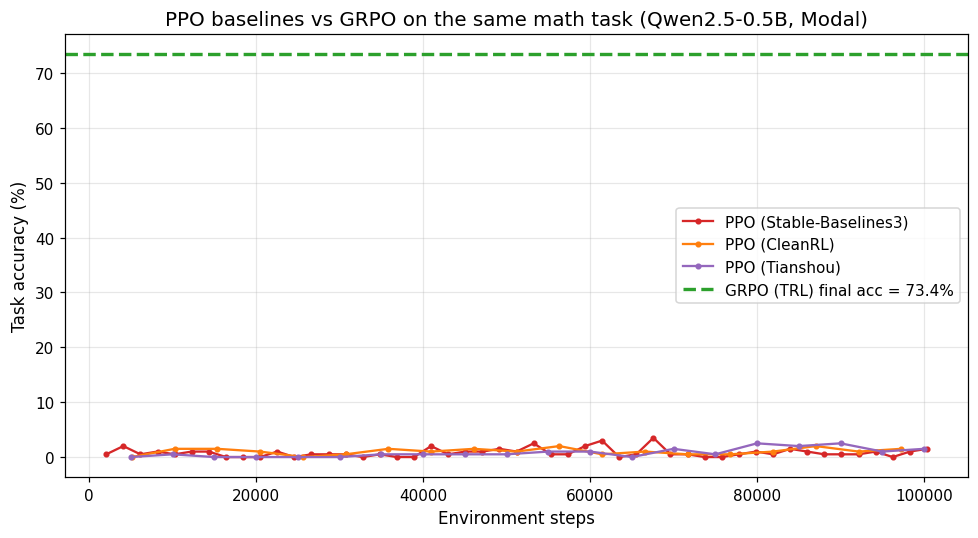

In [6]:
fig, ax = plt.subplots(figsize=(9, 5))
style = {
    "sb3_ppo_math":      ("#d62728", "PPO (Stable-Baselines3)"),
    "cleanrl_ppo_math":  ("#ff7f0e", "PPO (CleanRL)"),
    "tianshou_ppo_math": ("#9467bd", "PPO (Tianshou)"),
}
for exp, (color, label) in style.items():
    lc = np.array(modal[exp][0]["learning_curve"], dtype=float)  # seed 42
    ax.plot(lc[:, 0], lc[:, 1] * 100, marker="o", ms=3, color=color, label=label)

grpo_mean = cmp.loc[cmp.algorithm == "GRPO", "final_acc_mean"].iloc[0] * 100
ax.axhline(grpo_mean, ls="--", lw=2.2, color="#2ca02c",
           label=f"GRPO (TRL) final acc = {grpo_mean:.1f}%")
ax.set_xlabel("Environment steps")
ax.set_ylabel("Task accuracy (%)")
ax.set_title("PPO baselines vs GRPO on the same math task (Qwen2.5-0.5B, Modal)")
ax.legend(loc="center right")
fig.tight_layout(); show(fig)

## e. ZVF diagnostic — signal starvation in GRPO

The **Zero-Variance Fraction (ZVF)** is the share of GRPO groups in which every sampled
completion earns the *same* reward, so the group-relative advantage is zero and the batch
contributes no learning signal (paper **P2**). Using the per-step logs in
`platform_hybrid/platform_hybrid/experiments/results/groupsize_zvf_sweep.json`, we trace ZVF over training for each group size
(mean of 3 seeds), then show the cross-experiment ZVF summary table
(`platform_hybrid/platform_hybrid/experiments/results/zvf_summary.tsv`) with its deterministic failure labels.

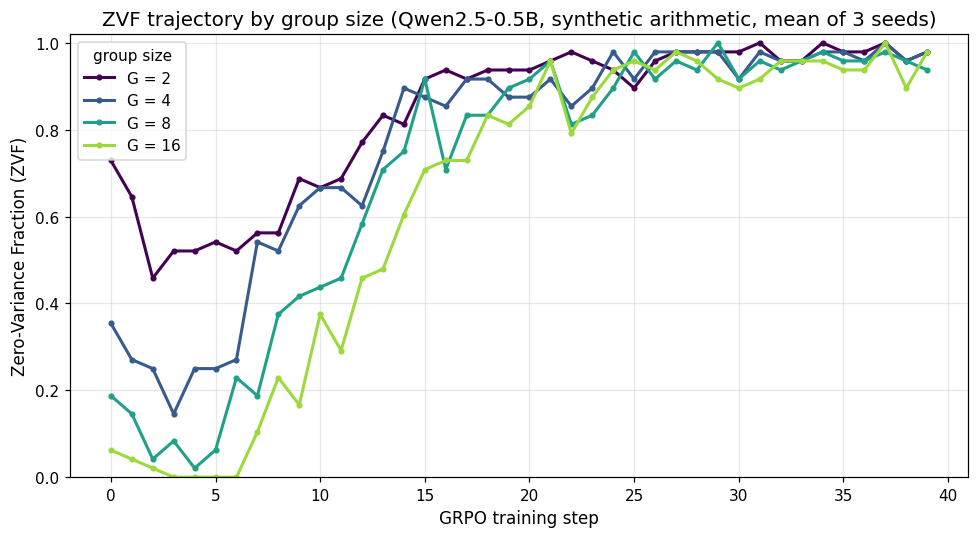

Larger groups keep ZVF lower for longer -> more non-degenerate learning signal per step.


In [7]:
sweep = json.load(open(REPO_ROOT / "platform_hybrid/experiments" / "results" / "groupsize_zvf_sweep.json"))
runs = sweep["runs"]
group_sizes = sorted({r["group_size"] for r in runs})

fig, ax = plt.subplots(figsize=(9, 5))
colors = plt.cm.viridis(np.linspace(0.0, 0.85, len(group_sizes)))
for gi, G in enumerate(group_sizes):
    gruns = [r for r in runs if r["group_size"] == G]
    steps = [s["step"] for s in gruns[0]["step_log"]]
    zmat = np.array([[s["zvf"] for s in r["step_log"]] for r in gruns])
    ax.plot(steps, zmat.mean(axis=0), color=colors[gi], lw=2, marker="o", ms=3, label=f"G = {G}")
ax.set_xlabel("GRPO training step")
ax.set_ylabel("Zero-Variance Fraction (ZVF)")
ax.set_title("ZVF trajectory by group size (Qwen2.5-0.5B, synthetic arithmetic, mean of 3 seeds)")
ax.set_ylim(0, 1.02)
ax.legend(title="group size")
fig.tight_layout(); show(fig)
print("Larger groups keep ZVF lower for longer -> more non-degenerate learning signal per step.")

In [8]:
zvf_sum = pd.read_csv(REPO_ROOT / "platform_hybrid/experiments" / "results" / "zvf_summary.tsv",
                      sep="\t", comment="#")
cols = ["experiment","model","task","group_size","n_seeds",
        "mean_zvf","peak","last10_avg","failure_label","n_steps"]
print("Cross-experiment ZVF diagnostic (higher mean_zvf = more signal-starved batches):")
display(zvf_sum[cols].head(12))
gsm = zvf_sum[zvf_sum["experiment"] == "tinker_gsm8k_zvf"]
if len(gsm):
    print(f"Flagship GRPO GSM8K (Qwen3-8B): mean ZVF = {gsm['mean_zvf'].mean():.3f} "
          f"-> label '{gsm['failure_label'].iloc[0]}' (healthy, not starved).")

Cross-experiment ZVF diagnostic (higher mean_zvf = more signal-starved batches):


,experiment,model,task,group_size,n_seeds,mean_zvf,peak,last10_avg,failure_label,n_steps
0,tinker_gsm8k_zvf,Qwen/Qwen3-8B,gsm8k,8,1,0.1300,0.7125,0.7125,converged,200
1,tinker_gsm8k_zvf,Qwen/Qwen3-8B,gsm8k,8,1,0.1900,0.6969,0.6969,converged,200
2,tinker_gsm8k_zvf,Qwen/Qwen3-8B,gsm8k,8,1,0.1550,0.6731,0.6731,converged,200
3,tinker_gsm8k_zvf,Qwen/Qwen3-8B,gsm8k,8,3,0.1583,0.7125,0.6942,converged,600
4,groupsize_zvf_sweep,Qwen/Qwen2.5-0.5B,arithmetic_synthetic,2,3,0.8380,0.9861,0.9771,converged,120
5,groupsize_zvf_sweep,Qwen/Qwen2.5-0.5B,arithmetic_synthetic,4,3,0.7635,0.9900,0.9714,converged,120
6,groupsize_zvf_sweep,Qwen/Qwen2.5-0.5B,arithmetic_synthetic,8,3,0.6906,0.9929,0.9732,converged,120
7,groupsize_zvf_sweep,Qwen/Qwen2.5-0.5B,arithmetic_synthetic,16,3,0.6312,0.9843,0.9837,converged,120
8,variance_mitigation,GRPO,math_verifiable_rl,8,1,0.4813,0.3844,0.3798,plateau,300
9,variance_mitigation,GRPO,math_verifiable_rl,8,1,0.4793,0.3862,0.3792,plateau,300


Flagship GRPO GSM8K (Qwen3-8B): mean ZVF = 0.158 -> label 'converged' (healthy, not starved).


## f. Group-size sweep

Paper **P3** frames group size as a **contrast-density** knob. The sweep table
`platform_hybrid/platform_hybrid/experiments/results/groupsize_zvf_sweep.tsv` (Qwen2.5-0.5B, synthetic arithmetic, 3 seeds each)
shows that as the group size G grows from 2 → 16 the **measured ZVF falls monotonically** while
**held-out accuracy stays high (~98%)**. We also overlay the *theoretical* ZVF at the observed
mean pass-rate, closing the loop between the descriptive diagnostic and its model.

Group-size sweep (Qwen2.5-0.5B, synthetic arithmetic, 3 seeds each):


,group_size,n_seeds,heldout_acc_mean,heldout_acc_se,last10_mean,mean_zvf,mean_reward_train,zvf_theory_at_mean_p
0,2,3,0.9817,0.0044,0.9771,0.8380,0.8398,0.7310
1,4,3,0.9883,0.0017,0.9714,0.7635,0.8625,0.5538
2,8,3,0.9900,0.0029,0.9732,0.6906,0.8694,0.3264
3,16,3,0.9783,0.0060,0.9837,0.6312,0.8731,0.1140


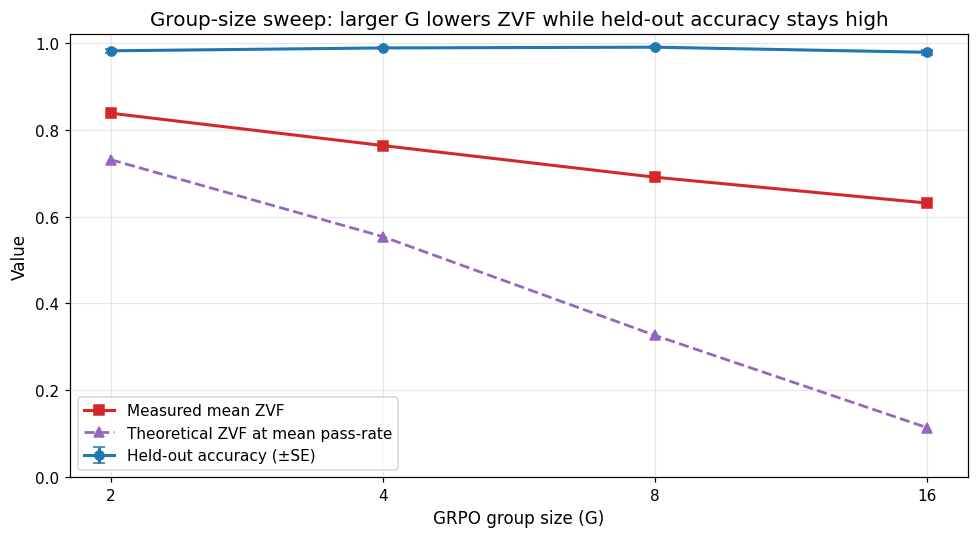

In [9]:
gs = pd.read_csv(REPO_ROOT / "platform_hybrid/experiments" / "results" / "groupsize_zvf_sweep.tsv", sep="\t")
gs = gs.rename(columns={"G": "group_size"})
print("Group-size sweep (Qwen2.5-0.5B, synthetic arithmetic, 3 seeds each):")
display(gs)

fig, ax = plt.subplots(figsize=(9, 5))
x = gs["group_size"].values
ax.errorbar(x, gs["heldout_acc_mean"], yerr=gs["heldout_acc_se"], marker="o", lw=2,
            capsize=4, color="#1f77b4", label="Held-out accuracy (±SE)")
ax.plot(x, gs["mean_zvf"], marker="s", lw=2, color="#d62728", label="Measured mean ZVF")
ax.plot(x, gs["zvf_theory_at_mean_p"], marker="^", ls="--", lw=1.8, color="#9467bd",
        label="Theoretical ZVF at mean pass-rate")
ax.set_xscale("log", base=2); ax.set_xticks(x); ax.set_xticklabels(x)
ax.set_xlabel("GRPO group size (G)"); ax.set_ylabel("Value"); ax.set_ylim(0, 1.02)
ax.set_title("Group-size sweep: larger G lowers ZVF while held-out accuracy stays high")
ax.legend(); fig.tight_layout(); show(fig)

## g. Fraud study (P8) — XGBoost tabular baseline

Paper **P8** ("Sensor and Scribe, Not Scorer") contrasts LLMs with a strong tabular model on
highly imbalanced **credit-card fraud** data. Here we load the precomputed XGBoost metrics from
`xgboost_results.json` (produced offline by `platform_local/train_xgboost.py` on the full dataset) and a small
1,000-row sample of `fraud_data.csv` to show the feature schema and the extreme class imbalance
that makes the task hard.

In [10]:
xgb = json.load(open(REPO_ROOT / "xgboost_results.json"))
print("XGBoost fraud-detection results (precomputed on the full dataset by platform_local/train_xgboost.py):")
display(pd.DataFrame([xgb]))

fraud = pd.read_csv(REPO_ROOT / "fraud_data.csv", nrows=1000)
print(f"\nfraud_data.csv sample: {fraud.shape[0]} rows x {fraud.shape[1]} cols; "
      f"features {list(fraud.columns[:6])} ... ; label column 'Class'")
display(fraud.head())
vc = fraud["Class"].value_counts()
print(f"Class balance in sample: legit={int(vc.get(0, 0))}, fraud={int(vc.get(1, 0))} "
      f"({vc.get(1, 0)/len(fraud)*100:.1f}% fraud)")

XGBoost fraud-detection results (precomputed on the full dataset by platform_local/train_xgboost.py):


,model,train_time_sec,infer_time_sec_per_10k,auc,f1,precision,recall
0,XGBoost,0.494768,0.006185,0.794241,0.356021,0.723404,0.236111



fraud_data.csv sample: 1000 rows x 25 cols; features ['V1', 'V2', 'V3', 'V4', 'V5', 'V6'] ... ; label column 'Class'


,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,Class,V_mean,V_std,V_max,V_min
0,-2.828224,-0.326484,1.481905,0.001775,3.409174,-3.045147,-0.520219,-1.380371,0.535742,-1.104227,0.078893,0.841975,2.476737,-1.348034,-6.517232,1.214249,1.729844,-0.323775,-0.763358,1.220185,0,-0.258330,2.192435,3.409174,-6.517232
1,-0.565217,-0.547902,-2.486542,-2.034469,-1.329607,0.885630,-2.119194,-0.559370,-0.977771,-3.098309,-1.651801,-2.027163,-0.248131,1.827927,1.867385,0.892987,0.159038,0.722015,2.544111,2.359490,0,-0.319345,1.684686,2.544111,-3.098309
2,0.612108,-0.011507,1.416179,-1.262384,-0.388172,-0.026085,1.446694,1.444120,1.744939,5.226571,0.879395,-2.303473,0.394729,-0.295721,2.295272,2.545165,-0.628177,-0.674610,-0.826145,-3.088665,0,0.425012,1.838101,5.226571,-3.088665
3,1.605092,-0.657201,1.874006,-0.252366,0.022594,1.566666,1.236106,0.758197,-1.679540,4.654440,0.773407,-2.289773,-1.196542,1.743414,5.184738,3.836879,-0.221875,0.200726,2.560685,-2.009112,0,0.885527,2.084300,5.184738,-2.289773
4,-1.326939,-0.404567,-1.691243,0.492084,2.278609,-1.666782,0.034600,1.116058,-0.333494,-2.140724,-1.501275,-1.887969,-0.816255,1.607345,-5.781192,-1.271552,-1.511690,-1.988346,-1.646083,-0.541031,0,-0.949022,1.690112,2.278609,-5.781192


Class balance in sample: legit=984, fraud=16 (1.6% fraud)


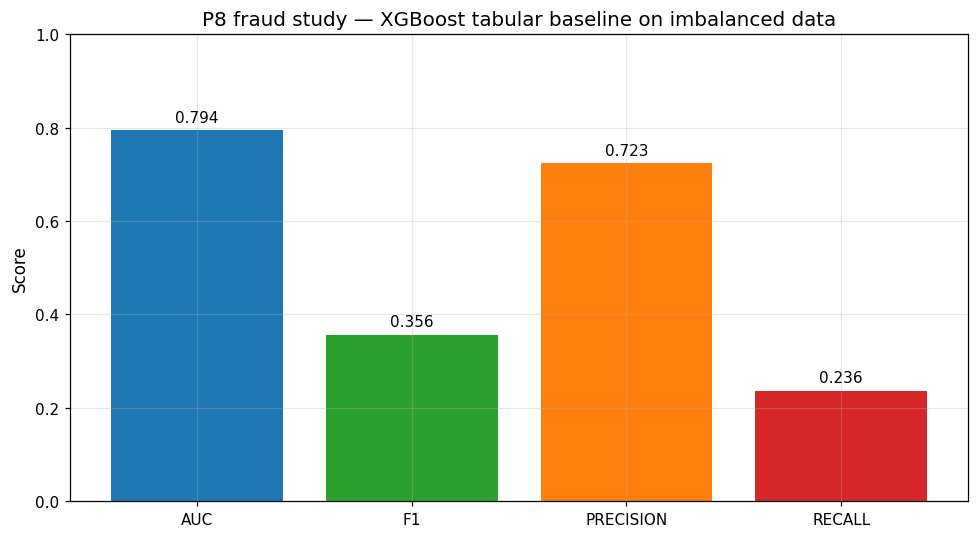

AUC=0.794 with high precision (0.723) but low recall (0.236) — the imbalance signature P8 examines.


In [11]:
fig, ax = plt.subplots(figsize=(9, 5))
keys = ["auc", "f1", "precision", "recall"]
vals = [xgb[k] for k in keys]
bars = ax.bar([k.upper() for k in keys], vals,
              color=["#1f77b4", "#2ca02c", "#ff7f0e", "#d62728"])
for b, v in zip(bars, vals):
    ax.text(b.get_x() + b.get_width()/2, v + 0.012, f"{v:.3f}", ha="center", va="bottom")
ax.set_ylim(0, 1.0); ax.set_ylabel("Score")
ax.set_title("P8 fraud study — XGBoost tabular baseline on imbalanced data")
fig.tight_layout(); show(fig)
print(f"AUC={xgb['auc']:.3f} with high precision ({xgb['precision']:.3f}) but low recall "
      f"({xgb['recall']:.3f}) — the imbalance signature P8 examines.")

## h. Closing — papers and reproduction

**Paper series (`sem 4 work/papers/`):**

| # | Paper | Demo section |
|---|-------|--------------|
| **P1** | Scaling Laws for GRPO Post-Training (cross-library, cross-scale) | b |
| **P2** | The Zero-Variance Fraction: a diagnostic for signal starvation | **e** |
| **P3** | Group Size in GRPO: contrast density and the bridge to DPO | **f** |
| **P4** | Length Bias and Held-Out Generalization in GRPO / Dr. GRPO | c |
| **P5** | Report the Stack, Not the Label: results are stack-conditioned | **d** |
| **P6** | GRPO-Registry: a machine-readable catalog of RL stacks | b |
| **P7** | From Diagnostic to Controller: adaptive group-size intervention | e, f |
| **P8** | LLM vs XGBoost in Credit-Card Fraud: Sensor and Scribe | **g** |

**Reproduction entry points:**
- `README.md` — project overview and framework map
- `REPRODUCE.md` — reviewer-oriented reproduction commands
- `ARTIFACT.md` — result-to-artifact mapping
- `sem 4 work/EXPERIMENTS.md` — paper-to-source / evidence map
- `platform_hybrid/experiments/experiment_summary.md` — consolidated experiment summary
- `platform_hybrid/experiments/results/` — result tables, per-step traces, and audit outputs

*Every figure and table above was regenerated live from these committed artifacts — fully
offline, no API keys, no training.*